# Hot Routes

In [6]:
!pip cache purge --quiet

In [7]:
!pip install contextily==1.6.2 \
             geopandas==1.1.1 \
             matplotlib==3.10.6 \
             shapely==2.1.1 --quiet

In [8]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt

from collections import Counter
from math import radians, sin, cos, sqrt, atan2
from pymongo import MongoClient
from shapely.geometry import Point, Polygon, shape

INFO:matplotlib.font_manager:generated new fontManager


In [9]:
try:
    client = MongoClient(connection_url_kai)
    db = client["hot_routes_db"]
    print("Connected to Kai successfully")
except Exception as e:
    print(f"Could not connect to Kai: '{e}'")

Connected to Kai successfully


In [10]:
buffers = list(db["bakerloo_line_buff"].find({}))

def crime_in_buffers_filter():
    # returns a $or filter: crimes within any of the buffer polygons
    return {
        "$or": [
            {"geometry": {"$geoWithin": {"$geometry": buf["geometry"]}}}
            for buf in buffers
        ]
    }

In [11]:
# Aggregate crimes by type

pipeline = [
    {"$match": crime_in_buffers_filter()},
    {"$group": {"_id": "$crime_type", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 5}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Crime counts by type in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No crimes found in the Bakerloo buffer.")

Crime counts by type in the Bakerloo buffer:
Theft from the person: 438
Public order: 349
Violence and sexual offences: 346
Other theft: 313
Criminal damage and arson: 125


In [12]:
# Aggregate crimes per month

pipeline = [
    {"$match": crime_in_buffers_filter()},
    {"$group": {"_id": "$month", "count": {"$sum": 1}}},
    {"$sort": {"_id": 1}}  # chronological order
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Crime counts per month in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No crimes found in the Bakerloo buffer.")

Crime counts per month in the Bakerloo buffer:
2024-01: 139
2024-02: 139
2024-03: 151
2024-04: 143
2024-05: 155
2024-06: 131
2024-07: 148
2024-08: 155
2024-09: 135
2024-10: 134
2024-11: 149
2024-12: 152
2025-01: 150


In [13]:
# LSOA coverage (distinct count)

pipeline = [
    {"$match": {**crime_in_buffers_filter(), "lsoa_name": {"$nin": [None, "nan"]}}},
    {"$group": {"_id": "$lsoa_name"}},
    {"$count": "distinct_lsoas"}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print(f"Number of distinct LSOAs in the Bakerloo buffer: {results[0]['distinct_lsoas']}")
else:
    print("No LSOAs found in the Bakerloo buffer.")

Number of distinct LSOAs in the Bakerloo buffer: 33


In [14]:
# Top 10 LSOAs by number of crimes

pipeline = [
    {"$match": {**crime_in_buffers_filter(), "lsoa_name": {"$nin": [None, "nan"]}}},
    {"$group": {"_id": "$lsoa_name", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Top 10 LSOAs in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No crimes found in any LSOA in the Bakerloo buffer.")

Top 10 LSOAs in the Bakerloo buffer:
Lambeth 036E: 212
Westminster 018A: 205
Westminster 018C: 159
Westminster 008D: 141
Westminster 013G: 132
Westminster 008A: 111
Westminster 020C: 90
Westminster 016B: 87
Southwark 034C: 80
Hammersmith and Fulham 001D: 66


In [15]:
# Top 5 LSOAs by specific crime type

crime_type_to_check = "Bicycle theft"

pipeline_top = [
    {"$match": {**crime_in_buffers_filter(), "crime_type": crime_type_to_check, "lsoa_name": {"$nin": [None, "nan"]}}},
    {"$group": {"_id": "$lsoa_name", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 5}
]

results = list(db.crimes.aggregate(pipeline_top))

if results:
    print(f"Top LSOAs for {crime_type_to_check} in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No LSOAs found for this crime type in the Bakerloo buffer.")

Top LSOAs for Bicycle theft in the Bakerloo buffer:
Westminster 018A: 9
Harrow 013G: 6
Hammersmith and Fulham 001D: 3
Southwark 034C: 3
Lambeth 036E: 3


In [16]:
# Bottom 5 LSOAs for a specific crime type

crime_type_to_check = "Bicycle theft"

pipeline_bottom = [
    {"$match": {**crime_in_buffers_filter(), "crime_type": crime_type_to_check, "lsoa_name": {"$nin": [None, "nan"]}}},
    {"$group": {"_id": "$lsoa_name", "count": {"$sum": 1}}},
    {"$sort": {"count": 1}},
    {"$limit": 5}
]

results = list(db.crimes.aggregate(pipeline_bottom))

if results:
    print(f"Bottom LSOAs for {crime_type_to_check} in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No LSOAs found for this crime type in the Bakerloo buffer.")

Bottom LSOAs for Bicycle theft in the Bakerloo buffer:
Westminster 016B: 1
Brent 032E: 1
Brent 008D: 1
Westminster 020C: 1
Brent 027G: 1


In [18]:
# Top 10 crimes per LSOA

pipeline = [
    {"$match": {**crime_in_buffers_filter(), "lsoa_name": {"$nin": [None, "nan"]}, "crime_type": {"$ne": None}}},
    {"$group": {"_id": {"lsoa": "$lsoa_name", "crime": "$crime_type"}, "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Top crimes per LSOA in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']['lsoa']} - {r['_id']['crime']}: {r['count']}")
else:
    print("No crimes found for any LSOA in the Bakerloo buffer.")

Top crimes per LSOA in the Bakerloo buffer:
Westminster 018C - Theft from the person: 48
Lambeth 036E - Theft from the person: 44
Westminster 018A - Violence and sexual offences: 41
Westminster 018A - Public order: 39
Westminster 018A - Other theft: 37
Lambeth 036E - Violence and sexual offences: 37
Lambeth 036E - Other theft: 36
Lambeth 036E - Public order: 36
Westminster 018C - Violence and sexual offences: 31
Westminster 018A - Theft from the person: 31


In [19]:
# Count crimes by reporting authority

pipeline = [
    {"$match": {**crime_in_buffers_filter(), "reported_by": {"$nin": [None, ""]}}},
    {"$group": {"_id": "$reported_by", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Crime counts by reporting authority in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("No crimes found for any reporting authority in the Bakerloo buffer.")

Crime counts by reporting authority in the Bakerloo buffer:
British Transport Police: 1881


In [20]:
# Count crimes by last outcome category

pipeline = [
    {"$match": {**crime_in_buffers_filter(), "last_outcome_category": {"$nin": [None, "", "nan"]}}},
    {"$group": {"_id": "$last_outcome_category", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Crime counts by last outcome category in the Bakerloo buffer:")
    for r in results:
        print(f"{r['_id']}: {r['count']}")
else:
    print("Crime counts by last outcome category in the Bakerloo buffer: 0 (no data available)")

Crime counts by last outcome category in the Bakerloo buffer: 0 (no data available)


In [21]:
# Top 10 closest crimes with counts by type

# Haversine function (distance in km)
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0
    dlon = radians(lon2 - lon1)
    dlat = radians(lat2 - lat1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Center near Elephant & Castle
center_lon, center_lat = -0.1005, 51.4965

# Get all crimes within the Bakerloo buffer
crimes_cursor = db.crimes.find(crime_in_buffers_filter())

# Compute distance and store
crimes_with_dist = []
for c in crimes_cursor:
    geom = c.get("geometry")
    if geom and "coordinates" in geom:
        lon, lat = geom["coordinates"]
        dist = haversine(center_lon, center_lat, lon, lat)
        c["distance_km"] = dist
        crimes_with_dist.append(c)

# Sort by distance and take top 10 closest
top_crimes = sorted(crimes_with_dist, key = lambda x: x["distance_km"])[:10]

if top_crimes:
    # Count crime types in the top 10
    crime_counts = Counter([c.get("crime_type", "Unknown") for c in top_crimes])

    print(f"Top 10 closest crimes to ({center_lat}, {center_lon}) inside the Bakerloo buffer:")
    for r in top_crimes:
        print(f"{r.get('crime_type', 'Unknown')} at {r.get('location', 'Unknown')} (Distance: {r['distance_km']:.3f} km)")

    print("\nCounts by crime type for these 10 closest crimes:")
    for crime, count in crime_counts.items():
        print(f"{crime}: {count}")
else:
    print(f"No crimes found inside the Bakerloo buffer near ({center_lat}, {center_lon}).")

Top 10 closest crimes to (51.4965, -0.1005) inside the Bakerloo buffer:
Public order at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Public order at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other theft at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other theft at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Public order at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other theft at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other crime at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other theft at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Public order at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)
Other theft at On or near Elephant And Castle (Lu Station) (Distance: 0.222 km)

Counts by crime type for these 10 closest crimes:
Public order: 4
Other theft: 5
Other crime: 1


In [22]:
# Bounding box filter

bbox = [[-0.1040, 51.4935], [-0.1000, 51.4975]]

results = db.crimes.find({
    **crime_in_buffers_filter(),
    "geometry": {"$geoWithin": {"$box": bbox}}
}).limit(10)

results_list = list(results)

if results_list:
    print(f"Crimes within bounding box {bbox} inside the Bakerloo buffer:")
    for r in results_list:
        print(f"{r.get('crime_type', 'Unknown')} at {r.get('location', 'Unknown')}")
else:
    print("No crimes found within this bounding box inside the Bakerloo buffer.")

Crimes within bounding box [[-0.104, 51.4935], [-0.1, 51.4975]] inside the Bakerloo buffer:
Theft from the person at On or near Elephant And Castle (Lu Station)
Public order at On or near Elephant And Castle (Lu Station)
Violence and sexual offences at On or near Elephant And Castle (Lu Station)
Other theft at On or near Elephant And Castle (Lu Station)
Other theft at On or near Elephant And Castle (Lu Station)
Bicycle theft at On or near Elephant And Castle (Lu Station)
Theft from the person at On or near Elephant And Castle (Lu Station)
Violence and sexual offences at On or near Elephant And Castle (Lu Station)
Bicycle theft at On or near Elephant And Castle (Lu Station)
Criminal damage and arson at On or near Elephant And Castle (Lu Station)


In [23]:
# Find crimes within a polygon

# Polygon of interest
polygon = {
    "type": "Polygon",
    "coordinates": [[
        [-0.122 - 0.014, 51.507 - 0.009], # SW
        [-0.122 + 0.014, 51.507 - 0.009], # SE
        [-0.122 + 0.014, 51.507 + 0.009], # NE
        [-0.122 - 0.014, 51.507 + 0.009], # NW
        [-0.122 - 0.014, 51.507 - 0.009]  # back to SW
    ]]
}

# Combined filter strictly Bakerloo AND intersects polygon
combined_filter = {
    "$and": [
        {
            "$or": [
                {"geometry": {"$geoWithin": {"$geometry": buf["geometry"]}}} 
                for buf in buffers
            ]
        },
        {"geometry": {"$geoWithin": {"$geometry": polygon}}}
    ]
}

results = list(db.crimes.find(combined_filter).limit(10))

if results:
    print("Crimes strictly inside Bakerloo buffers that also intersect the polygon:")
    for r in results:
        print(f"{r.get('crime_type', 'Unknown')} at {r.get('location', 'Unknown')}")
else:
    print("No crimes found strictly inside Bakerloo buffers that intersect the polygon.")

Crimes strictly inside Bakerloo buffers that also intersect the polygon:
Theft from the person at On or near Waterloo  (London) (Station)
Theft from the person at On or near Piccadilly Circus (Lu Station)
Theft from the person at On or near Charing Cross (Lu Station)
Public order at On or near Colchester (Station)
Other theft at On or near Waterloo (East) (Station)
Vehicle crime at On or near Colchester (Station)
Violence and sexual offences at On or near Charing Cross (Lu Station)
Other theft at On or near Embankment (Lu Station)
Violence and sexual offences at On or near Waterloo  (London) (Station)
Theft from the person at On or near Piccadilly Circus (Lu Station)


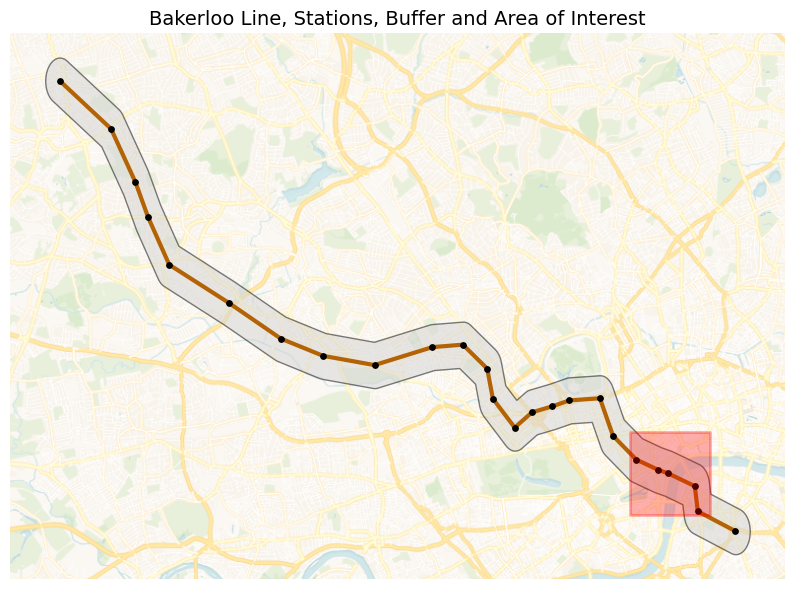

In [24]:
cursor = db["bakerloo_stops"].find()
bakerloo_stops = gpd.GeoDataFrame(
    ({**doc, "geometry": Point(doc["location"]["coordinates"])} for doc in cursor),
    crs = 4326
).drop(columns = ["_id", "location"])

cursor = db["bakerloo_sections"].find()
bakerloo_sections = gpd.GeoDataFrame(
    ({**doc, "geometry": shape(doc["geometry"])} for doc in cursor),
    crs = 4326
).drop(columns = ["_id"])

cursor = db["bakerloo_line_buff"].find()
bakerloo_line_buff = gpd.GeoDataFrame(
    ({**doc, "geometry": shape(doc["geometry"])} for doc in cursor),
    crs = 4326
).drop(columns = ["_id"])

# Polygon of interest
polygon_coords = [
    [-0.136, 51.498], # SW
    [-0.108, 51.498], # SE
    [-0.108, 51.516], # NE
    [-0.136, 51.516], # NW
    [-0.136, 51.498]  # back to SW
]
polygon = Polygon(polygon_coords)
polygon_area = gpd.GeoDataFrame({"name": ["Area"]}, geometry = [polygon], crs = 4326)

# Plot
fig, ax = plt.subplots(figsize = (10, 10))

# Bakerloo buffer
bakerloo_line_buff.to_crs(3857).plot(
    ax = ax,
    color = "lightgrey",
    edgecolor = "black",
    alpha = 0.5,
    zorder = 2
)

bakerloo_sections.to_crs(3857).plot(
    ax = ax,
    color = "#B36305",
    linewidth = 3,
    zorder = 3
)

bakerloo_stops.to_crs(3857).plot(
    ax = ax,
    color = "black",
    markersize = 15,
    zorder = 4
)

polygon_area.to_crs(3857).plot(
    ax = ax,
    color = "red",
    edgecolor = "red",
    alpha = 0.3,
    linewidth = 2,
    zorder = 5
)

# Add basemap
cx.add_basemap(ax, source = cx.providers.CartoDB.VoyagerNoLabels, attribution = "", zorder = 1)

ax.set_axis_off()
ax.set_title("Bakerloo Line, Stations, Buffer and Area of Interest", fontsize = 14)
plt.show()

In [25]:
# Find crimes near a point with $near

center_point = {"type": "Point", "coordinates": [-0.1005, 51.4965]}
max_distance_m = 300

results = db.crimes.find({
    **crime_in_buffers_filter(),
    "geometry": {
        "$near": {
            "$geometry": center_point,
            "$maxDistance": max_distance_m
        }
    }
}).limit(10)

results_list = list(results)

if results_list:
    print(f"Crimes within {max_distance_m} meters of center inside the Bakerloo buffer:")
    for r in results_list:
        print(f"{r.get('crime_type', 'Unknown')} at {r.get('location', 'Unknown')}")
else:
    print("No crimes found within the specified radius inside the Bakerloo buffer.")

Crimes within 300 meters of center inside the Bakerloo buffer:
Theft from the person at On or near Elephant And Castle (Lu Station)
Criminal damage and arson at On or near Elephant And Castle (Lu Station)
Violence and sexual offences at On or near Elephant And Castle (Lu Station)
Theft from the person at On or near Elephant And Castle (Lu Station)
Other theft at On or near Elephant And Castle (Lu Station)
Other theft at On or near Elephant And Castle (Lu Station)
Public order at On or near Elephant And Castle (Lu Station)
Possession of weapons at On or near Elephant And Castle (Lu Station)
Violence and sexual offences at On or near Elephant And Castle (Lu Station)
Bicycle theft at On or near Elephant And Castle (Lu Station)


In [26]:
# Find crimes within multiple disjoint polygons

# Elephant & Castle coordinates
elephant_castle = [-0.1005, 51.4965]

# Harrow & Wealdstone coordinates
harrow_wealdstone = [-0.337, 51.592]

# Create square buffers (~500m) around each location
def create_square_buffer(center, size_deg=0.0045 / 2):
    lon, lat = center
    return {
        "type": "Polygon",
        "coordinates": [[
            [lon - size_deg, lat - size_deg],
            [lon + size_deg, lat - size_deg],
            [lon + size_deg, lat + size_deg],
            [lon - size_deg, lat + size_deg],
            [lon - size_deg, lat - size_deg]
        ]]
    }

polygon1 = create_square_buffer(elephant_castle)
polygon2 = create_square_buffer(harrow_wealdstone)

pipeline = [
    {
        "$match": {
            "$or": [
                {"geometry": {"$geoWithin": {"$geometry": polygon1}}},
                {"geometry": {"$geoWithin": {"$geometry": polygon2}}}
            ]
        }
    },
    {
        "$group": {
            "_id": {
                "location": "$location",
                "crime_type": "$crime_type"
            },
            "count": {"$sum": 1}
        }
    },
    {
        "$group": {
            "_id": "$_id.location",
            "crimes": {
                "$push": {
                    "crime_type": "$_id.crime_type",
                    "count": "$count"
                }
            },
            "total": {"$sum": "$count"}
        }
    },
    {
        "$project": {
            "crimes": 1,
            # Convert total to integer
            "total": {"$toInt": "$total"}
        }
    },
    {"$limit": 10}
]

results = list(db.crimes.aggregate(pipeline))

if results:
    print("Counts by location and crime type:")
    for r in results:
        loc = r["_id"] or "Unknown"
        print(f"\n{loc} (Total: {r['total']}):")
        for c in r["crimes"]:
            print(f"  {c['crime_type']}: {c['count']}")
else:
    print("No crimes found in the specified polygons.")

Counts by location and crime type:

On or near Elephant And Castle (Lu Station) (Total: 80):
  Other theft: 16
  Criminal damage and arson: 9
  Other crime: 1
  Theft from the person: 23
  Robbery: 1
  Violence and sexual offences: 11
  Bicycle theft: 3
  Possession of weapons: 1
  Public order: 15

On or near Harrow & Wealdstone (Lu Station) (Total: 61):
  Vehicle crime: 1
  Public order: 15
  Violence and sexual offences: 11
  Criminal damage and arson: 4
  Theft from the person: 11
  Bicycle theft: 6
  Other theft: 9
  Robbery: 4
